In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk


In [26]:
reviews = pd.read_csv('data/IMDB Dataset.csv')

In [27]:
reviews.shape

(50000, 2)

In [28]:
reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [29]:
reviews['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [30]:
reviews.isnull().sum()

review       0
sentiment    0
dtype: int64

In [31]:
reviews.duplicated().sum()

np.int64(418)

In [32]:
df = reviews

In [33]:
df['review'].str.len().describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review, dtype: float64

In [34]:
import textwrap

print(textwrap.fill(df['review'].iloc[0]))

One of the other reviewers has mentioned that after watching just 1 Oz
episode you'll be hooked. They are right, as this is exactly what
happened with me.<br /><br />The first thing that struck me about Oz
was its brutality and unflinching scenes of violence, which set in
right from the word GO. Trust me, this is not a show for the faint
hearted or timid. This show pulls no punches with regards to drugs,
sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ as that is the nickname given to the Oswald
Maximum Security State Penitentary. It focuses mainly on Emerald City,
an experimental section of the prison where all the cells have glass
fronts and face inwards, so privacy is not high on the agenda. Em City
is home to many..Aryans, Muslims, gangstas, Latinos, Christians,
Italians, Irish and more....so scuffles, death stares, dodgy dealings
and shady agreements are never far away.<br /><br />I would say the
main appeal of the show is due to the fac

In [35]:
def clean_text(text):

  text = text.lower()

  # remove html tag
  text = re.sub(r'<.*?>', " ", text)

  # remove white space
  text = re.sub(r'\s+', ' ', text).strip()

  # remove URLs
  text = re.sub(r'http\S+|www\S+', ' ', text)

  # remove special characters
  text = re.sub(r"[^a-zA-Z\s']", ' ', text)

  return text

In [36]:
df['review'] = df['review'].apply(clean_text)


In [37]:
df.head(5)

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,petter mattei's love in the time of money is...,positive


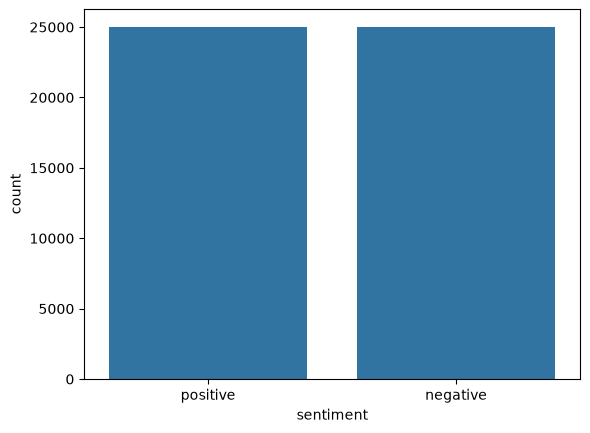

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="sentiment")
plt.show()

In [39]:
df['review_length'] = df['review'].str.len()

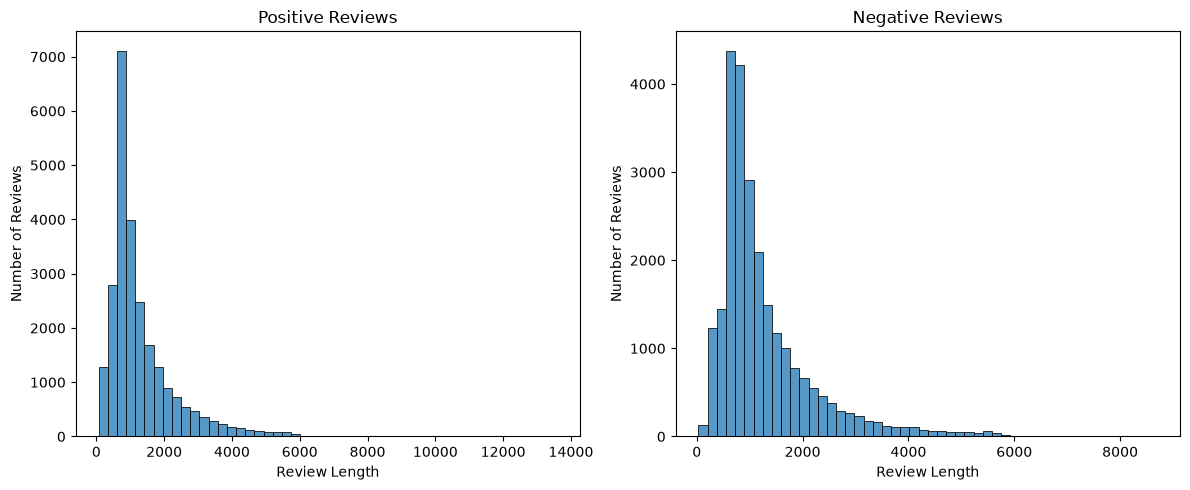

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    df[df['sentiment'] == 'positive']['review_length'],
    bins=50,
    ax=axes[0]
)
axes[0].set_title("Positive Reviews")
axes[0].set_xlabel("Review Length")
axes[0].set_ylabel("Number of Reviews")

sns.histplot(
    df[df['sentiment'] == 'negative']['review_length'],
    bins=50,
    ax=axes[1]
)
axes[1].set_title("Negative Reviews")
axes[1].set_xlabel("Review Length")
axes[1].set_ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [41]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
  df['review'],
  df['sentiment'],
  test_size=0.2,
  random_state=42,
  stratify=df['sentiment']
)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
  max_features = 50000,
  ngram_range=(1,2)
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

In [43]:
print('test split')
print(x_test_tfidf.shape)
print('train split')
print(x_train_tfidf.shape)

test split
(10000, 50000)
train split
(40000, 50000)


In [44]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    max_features=50000,
    ngram_range=(1, 2)
)

x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

In [45]:
print('test split')
print(x_test_bow.shape)
print('train split')
print(x_train_bow.shape)

test split
(10000, 50000)
train split
(40000, 50000)


In [46]:
from sklearn.linear_model import LogisticRegression

bow_model = LogisticRegression(max_iter = 1000)
tfidf_model = LogisticRegression(max_iter = 1000)

In [47]:
bow_model.fit(x_train_bow, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [48]:
tfidf_model.fit(x_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [49]:
y_pred_bow = bow_model.predict(x_test_bow)
y_pred_tfidf = tfidf_model.predict(x_test_tfidf)

In [50]:
from sklearn.metrics import accuracy_score,classification_report

# BOW
print('BOW')
print('Accuracy score: ')
print(accuracy_score(y_test,y_pred_bow))
print('classification report: ')
print(classification_report(y_test,y_pred_bow))

# TF-IDF
print('\nTF-IDF')
print('Accuracy score: ')
print(accuracy_score(y_test,y_pred_tfidf))
print('classification report: ')
print(classification_report(y_test,y_pred_tfidf))

BOW
Accuracy score: 
0.9034
classification report: 
              precision    recall  f1-score   support

    negative       0.91      0.90      0.90      5000
    positive       0.90      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


TF-IDF
Accuracy score: 
0.9071
classification report: 
              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



**As tf-idf performs better than BOW we will select it after comparision.**


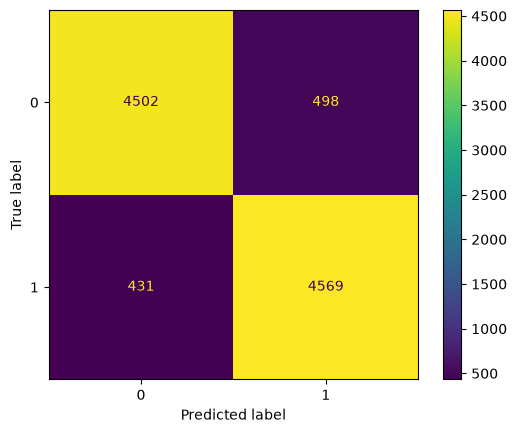

In [51]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred_tfidf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

**Checking why model predicts wrongly**

In [52]:
error_df = pd.DataFrame({
  'review' : x_test,
  'actual' : y_test,
  'predicted' : y_pred_tfidf
})

In [53]:
error = error_df[error_df['actual'] != error_df['predicted']]
error.head()

,review,actual,predicted
39791,the story of the bride fair is an amusing and ...,negative,positive
40714,little quentin seems to have mastered the art ...,negative,positive
4142,the movie 'gung ho ' the story of carlson's m...,negative,positive
11840,i had known brad linaweaver at florida state u...,negative,positive
21889,after having watched darwin's nightmare one m...,negative,positive


In [54]:
print(textwrap.fill(error['review'].iloc[4]))

after having watched darwin's nightmare  one must have the impression
of tanzania being a living hell  with its population being quasi
slaves delivering the finest fish to the well fed europeans while
leaving the fish bones to the starving population  in exchange for the
fish they get western made weapons  which the mainly unemployed
population eagerly awaits to use  because being a soldier is their
only source of income  so everything is all dark with trade as the
incarnation of evil and source of all misery  not quite  fortunately
darwin's nightmare shows the dark sides only and completely spares the
positive aspects  in fact  the documentary hardly tells anything about
the economic and ecologic importance the victoriaperch has for the
region  for the countries around lake victoria the victoriaperch is
the second to third most important source of income  the wages in the
fishing industry are way above average  tanzania has banned huge
trawlers to secure the jobs of thousands of fishe

In [55]:
print(len(error))

929


**After error analysis it can be said that**


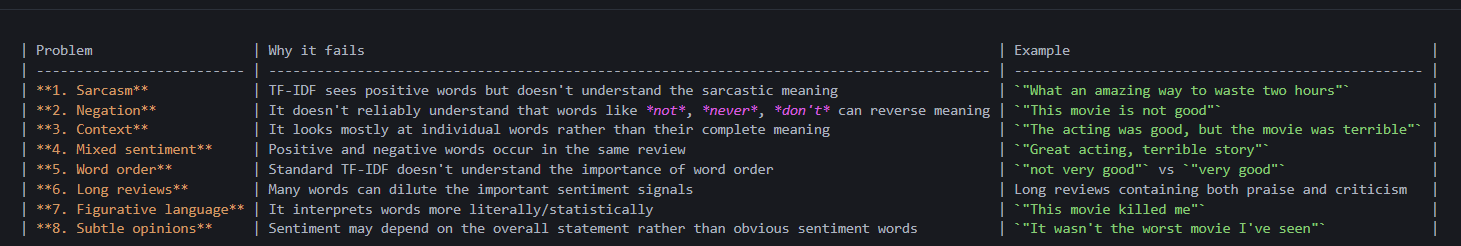


In [56]:
from sklearn.pipeline import Pipeline


model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['negative','positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",50000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [57]:
y_pred = model.predict(x_test)


In [58]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9071
              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [62]:
import pickle

with open("sentiment_pipeline.pkl", "wb") as file:
    pickle.dump(model, file)

In [63]:
with open("sentiment_pipeline.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [64]:
test_reviews = [
    "This movie was absolutely fantastic. I loved every minute of it.",
    "This was a terrible movie. I completely hated it.",
    "The movie was okay, but the ending was disappointing.",
    "One of the best movies I have ever watched.",
    "What a complete waste of time."
]

pred = loaded_model.predict(test_reviews)
prob = loaded_model.predict_proba(test_reviews)


for review, pred, prob in zip(test_reviews, pred, prob):
  print('Review: ',review)
  print('Prediction: ', pred)
  print('Confidence: ', max(prob))

  print('-' * 50)

Review:  This movie was absolutely fantastic. I loved every minute of it.
Prediction:  positive
Confidence:  0.8306182947129653
--------------------------------------------------
Review:  This was a terrible movie. I completely hated it.
Prediction:  negative
Confidence:  0.9616600412725387
--------------------------------------------------
Review:  The movie was okay, but the ending was disappointing.
Prediction:  negative
Confidence:  0.9315161627171578
--------------------------------------------------
Review:  One of the best movies I have ever watched.
Prediction:  positive
Confidence:  0.8849176869039775
--------------------------------------------------
Review:  What a complete waste of time.
Prediction:  negative
Confidence:  0.9941349608362785
--------------------------------------------------
